# Introduction to the project

## 1. Environment setup

In [1]:
!hpc-ticket
!hpc-mount wissdaten

In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

# 2. epidemiological data

/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:380: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:391: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1100x3000 with 11 Axes>,
 <Axes: title={'center': 'incidence in node: 9'}>)

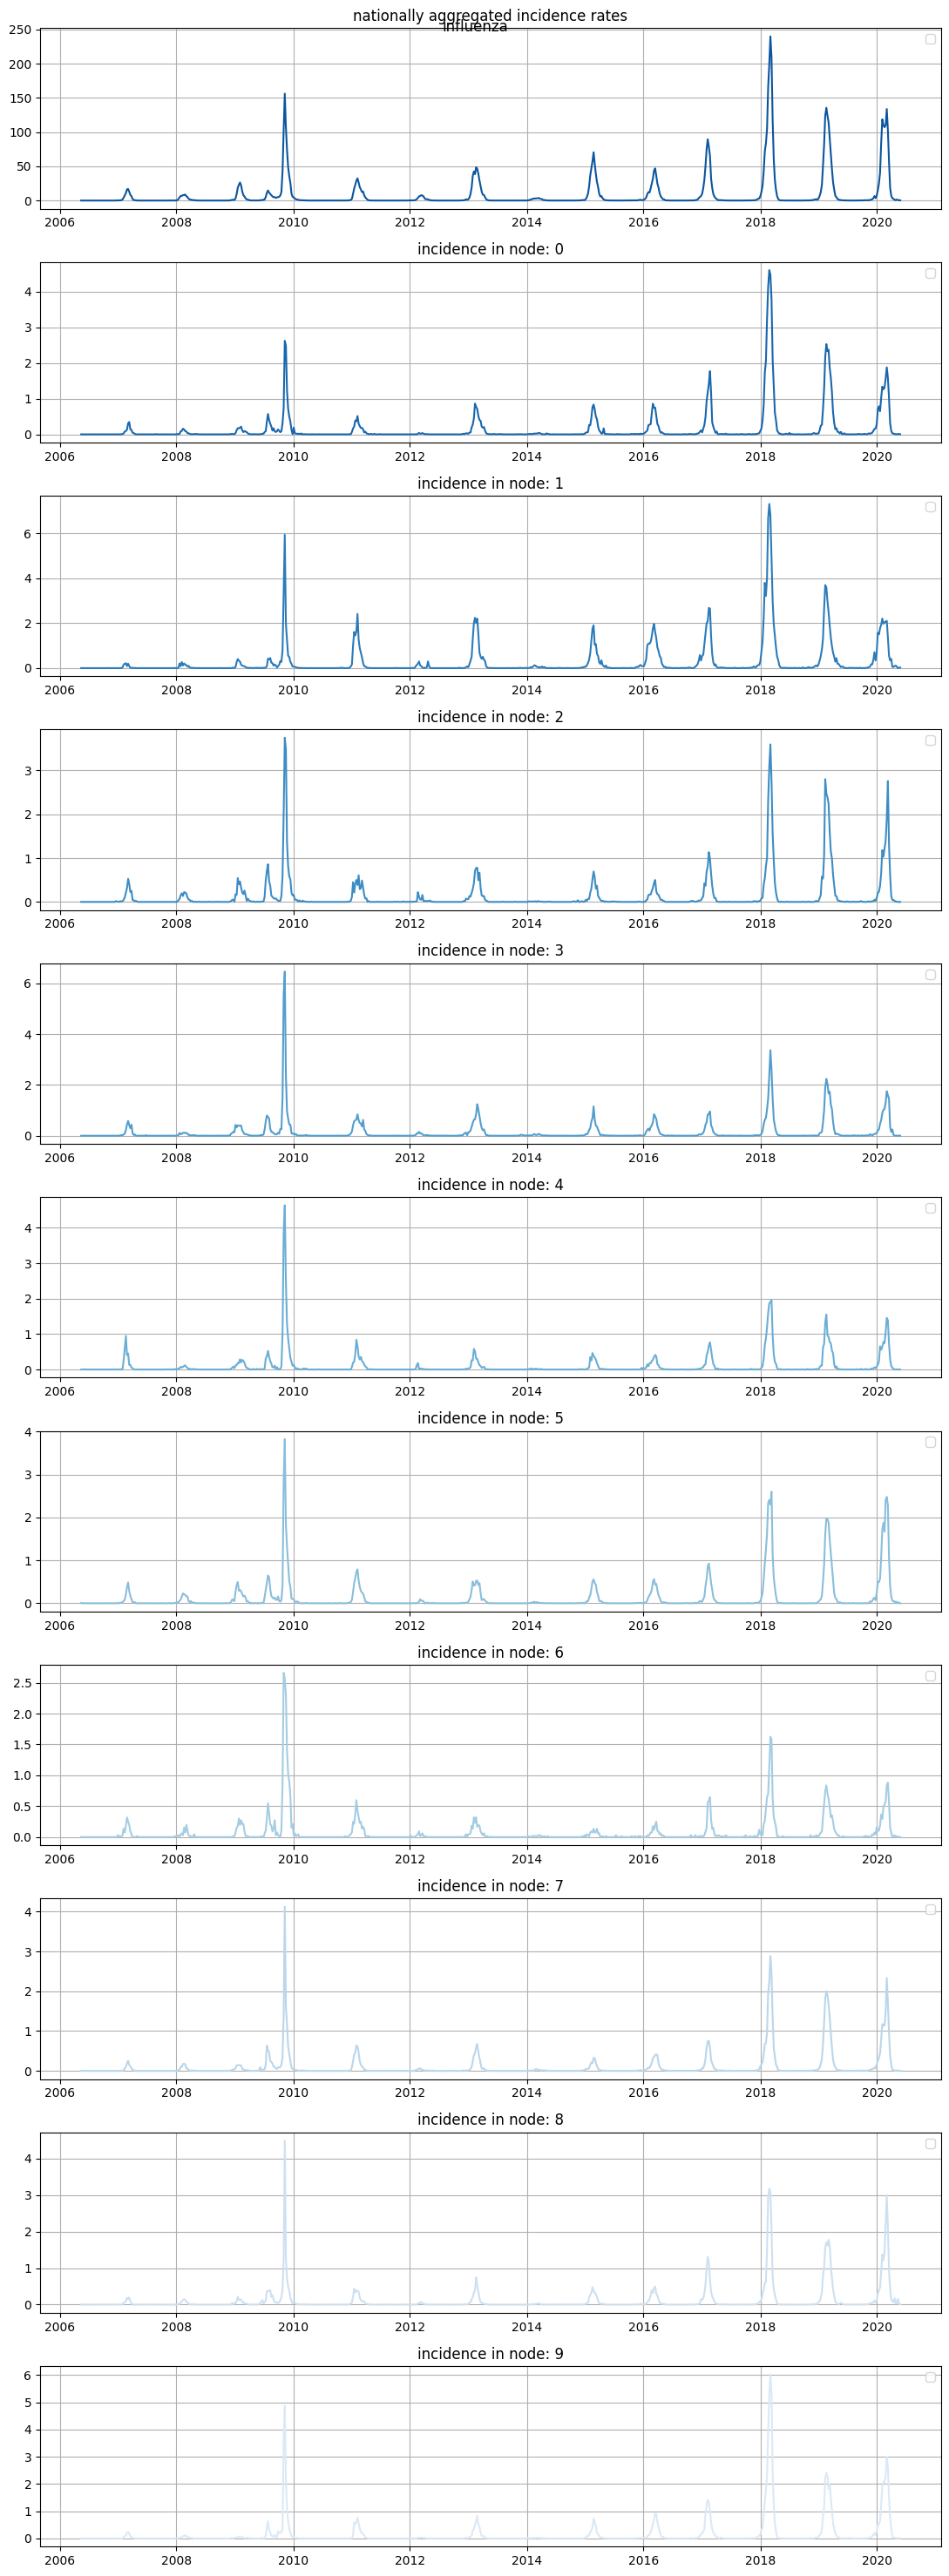

In [3]:
epidata_nuts2 = EpiDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize()

epidata_nuts2.preview(range(0,10), 'raw')


/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:181: UserWarning: 1 rows with missing tokenized IDs will be dropped from 'shapedata'. Dropped original IDs: ['11000']
  warnings.warn(
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:380: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:391: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1100x900 with 4 Axes>,
 <Axes: title={'center': 'incidence in node: 223'}>)

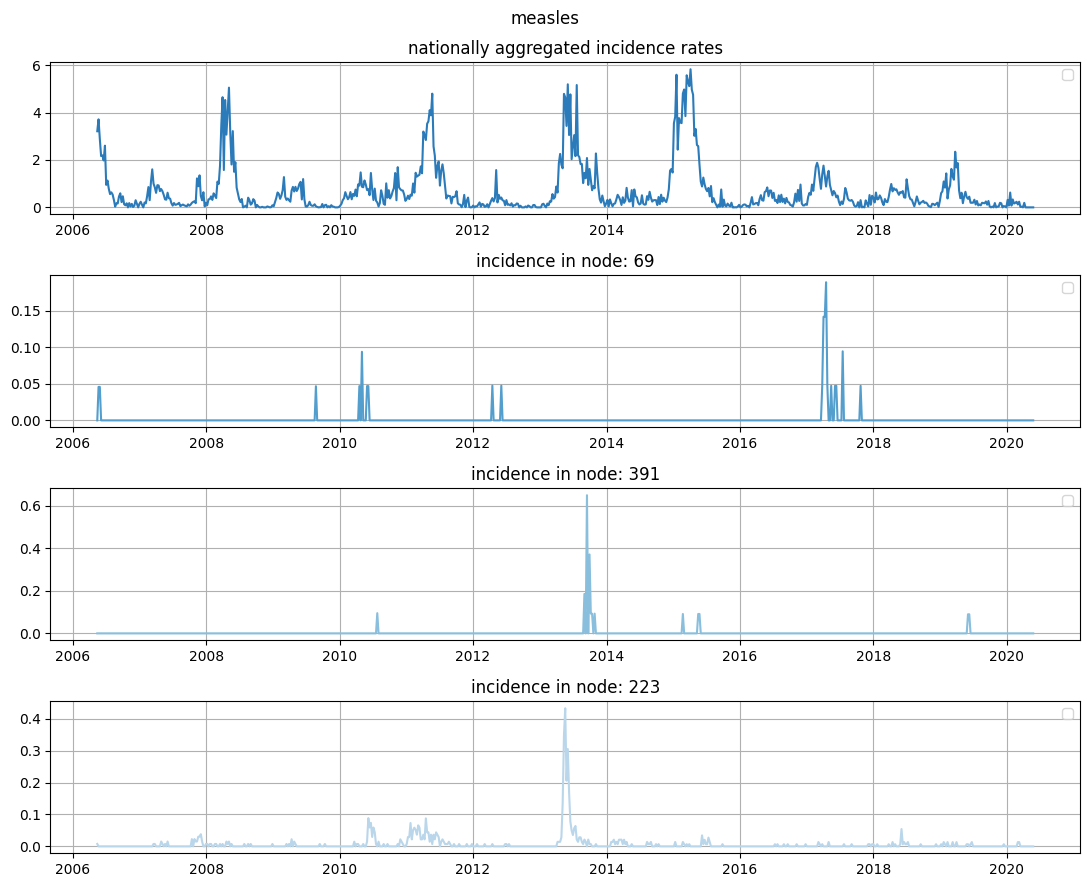

In [14]:
epidata_nuts3 = EpiDataLoader('measles', data_env, nuts_level='nuts3', min_date='2006-05-15',max_date='2020-06-01', include_population=True)
epidata_nuts3.add_time_features()
epidata_nuts3.log_transform_target()
epidata_nuts3.set_splits()
epidata_nuts3.normalize()
epidata_nuts3.add_lagged_features(lags = range(2,3))
epidata_nuts3.finalize()

epidata_nuts3.preview([69, 391, 223], 'raw')


/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:380: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:391: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1100x3000 with 11 Axes>,
 <Axes: title={'center': 'incidence in node: 9'}>)

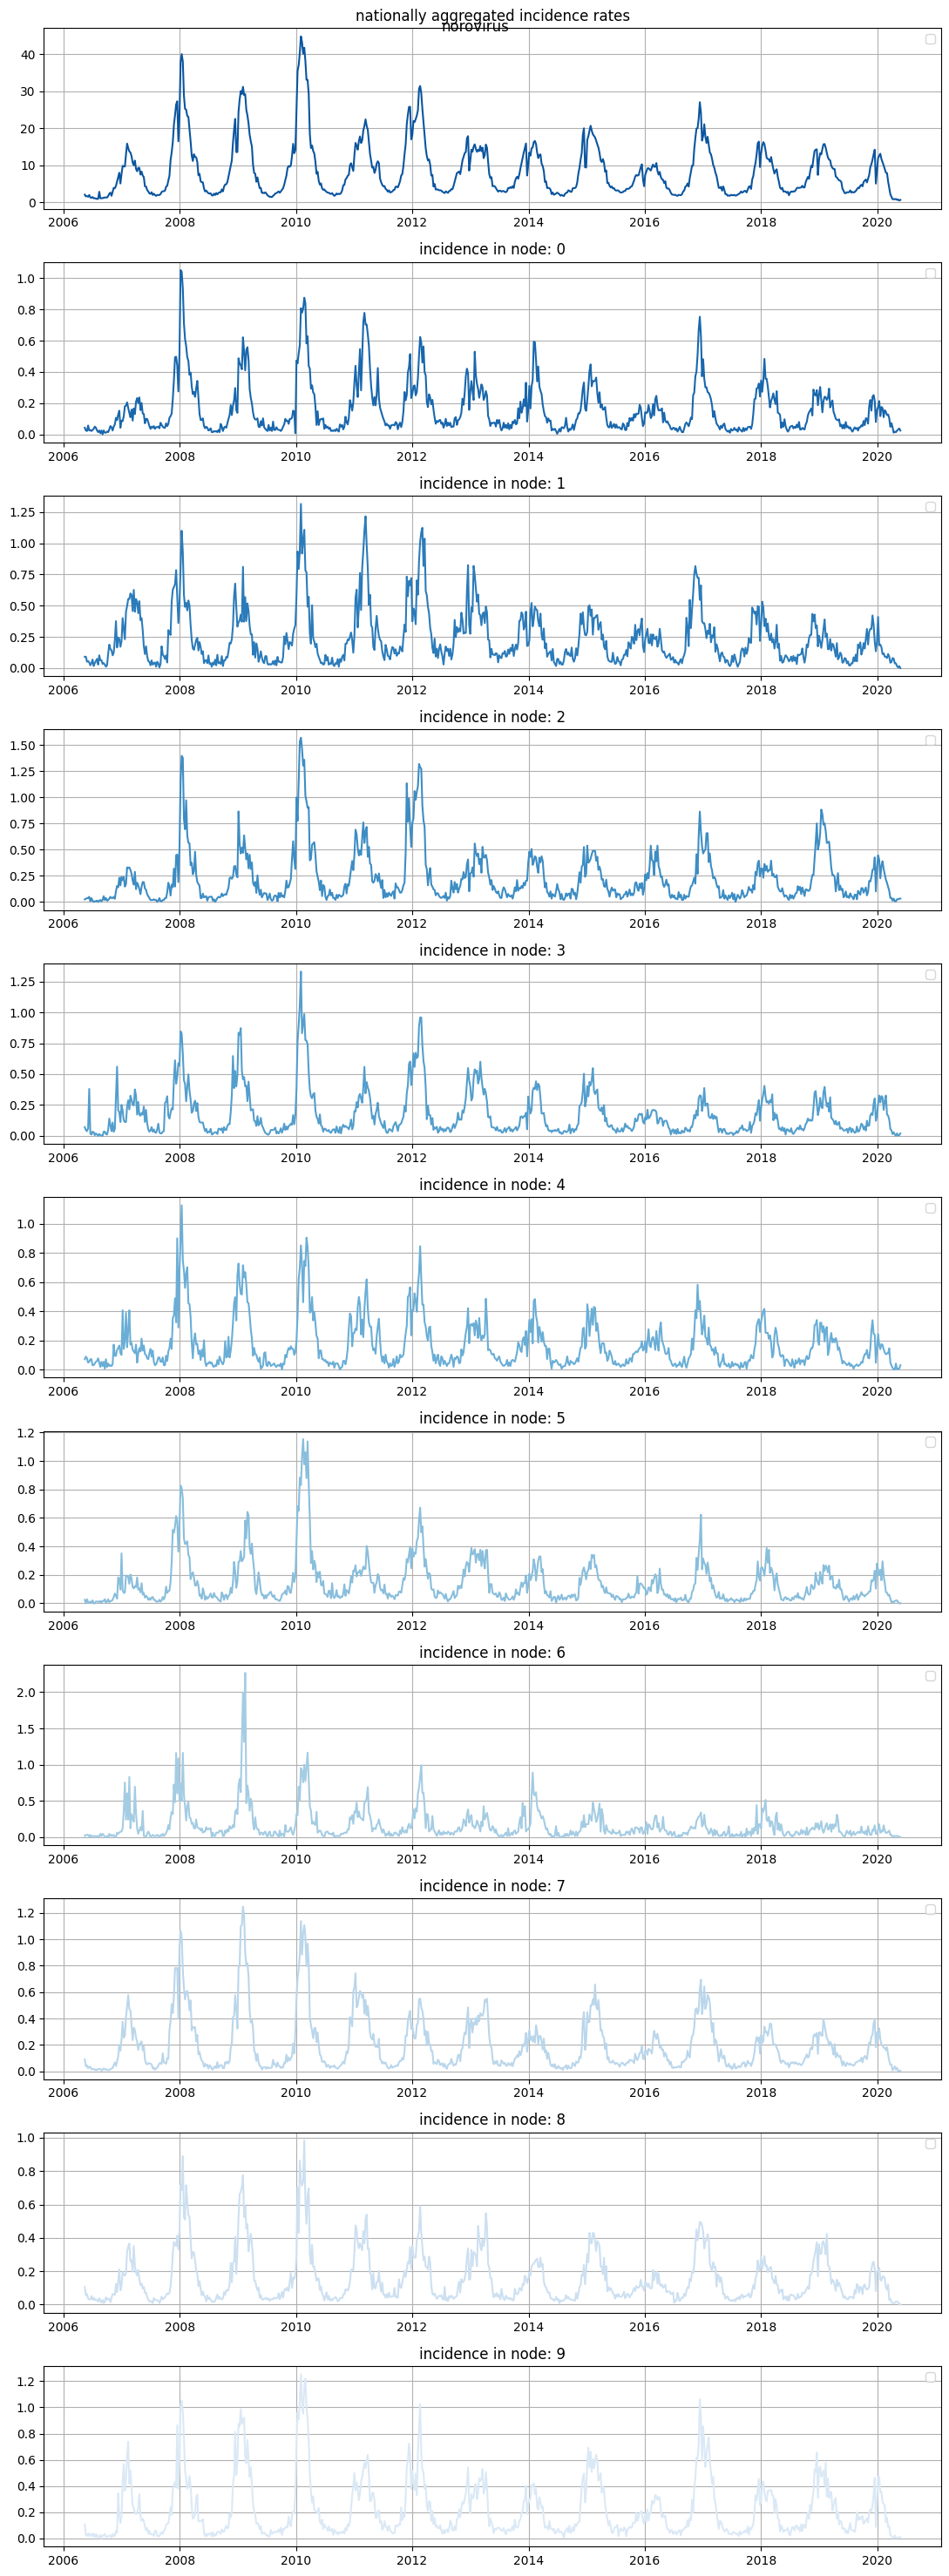

In [7]:
epidata_nuts2 = EpiDataLoader('norovirus', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize()

epidata_nuts2.preview(range(0,10), 'raw')


GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)


<EpiDataLoader(disease=influenza,
data stages: ['context', 'raw', 'processed', 'processed_split', 'normalized', 'final', 'final-horizon'], 
features: ['population_size', 'timestamp_sin', 'timestamp_cos', 'incidence_lag2'], 
nuts_level=nuts2, 
date_range=(2006-05-15 - 2020-08-24), 
nodes=38, data_rows=28310
split summary: train / val / test: 85.8% / 7.1% / 7.1% (original timespan)

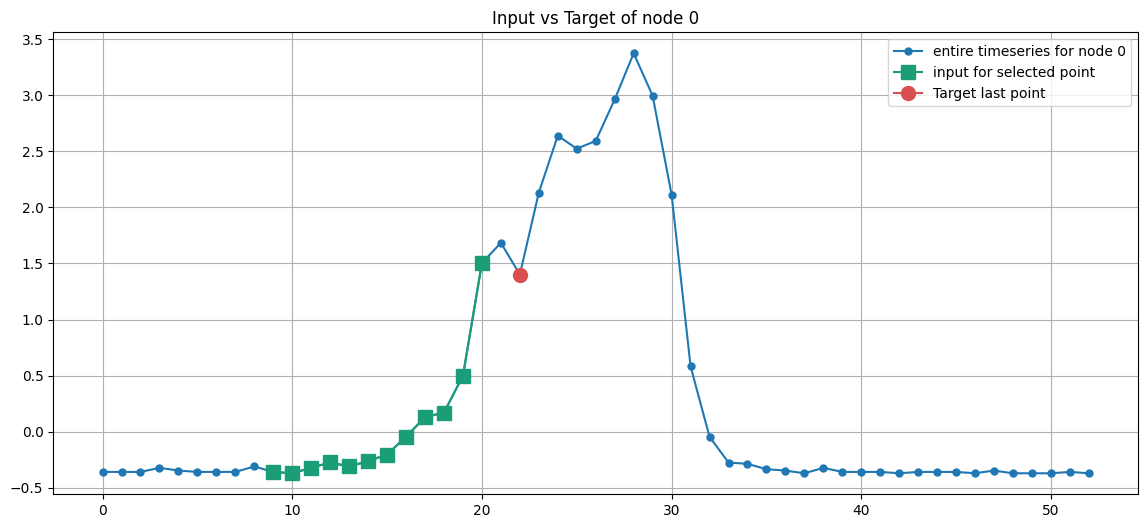

In [ ]:
from src.dataloading.deepdataloader import GNNDataLoader
epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=1)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize().retrieve_graph(graphname = 'identity_graph').construct_dataloaders()

epidata_nuts2.preview_dataloader(0)


# 3. Graphs

In [5]:
from src.dataloading.graphconstructor import GraphConstructor

graphconstruction = GraphConstructor(graph_dir = 'data/graphs', 
                                     epidata   = epidata_nuts2,
                                     id_col    = 'node')

graphconstruction.generate_graph(
    method='identity_graph', 
    name_addition='',
    self_connection='1'
)

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    name_addition='selfmn',
    self_connection='1'
)

graphconstruction.generate_graph(
    method='gravity_model', 
    scaling_method='log',
    max_distance = 250_000,
    alpha = 1.5,
    density_control = 'adaptive',
    name_addition='selfmn_adaptive',
    self_connection='mean'
)

graphconstruction.generate_graph(
    method='gravity_model', 
    scaling_method='log',
    max_distance = 250_000,
    alpha = 1.5,
    density_control = 'distance_bands',
    name_addition='selfmn_distance_bands',
    self_connection='mean'
)

graphconstruction.rename_graph('gravity_model_selfmn_distance_bands_log', 'gravity_model_sparse_selfmn')
graphconstruction.rename_graph('gravity_model_selfmn_adaptive_log', 'gravity_model_dense_selfmn')

graphconstruction.save_graph('gravity_model_sparse_selfmn')
graphconstruction.save_graph('gravity_model_dense_selfmn')
graphconstruction.save_graph('boolean_neighbors_selfmn')


identity_graph generated
boolean_neighbors_selfmn generated
gravity_model_selfmn_adaptive_log generated
gravity_model_selfmn_distance_bands_log generated
gravity_model_selfmn_distance_bands_log has been replaced by gravity_model_sparse_selfmn
gravity_model_selfmn_adaptive_log has been replaced by gravity_model_dense_selfmn
edge index gravity_model_sparse_selfmn saved to data/graphs/nuts2
edge weight gravity_model_sparse_selfmn saved to data/graphs/nuts2
edge index gravity_model_dense_selfmn saved to data/graphs/nuts2
edge weight gravity_model_dense_selfmn saved to data/graphs/nuts2
edge index boolean_neighbors_selfmn saved to data/graphs/nuts2
edge weight boolean_neighbors_selfmn saved to data/graphs/nuts2


/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:181: UserWarning: 1 rows with missing tokenized IDs will be dropped from 'shapedata'. Dropped original IDs: ['11000']
  warnings.warn(
/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:443: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


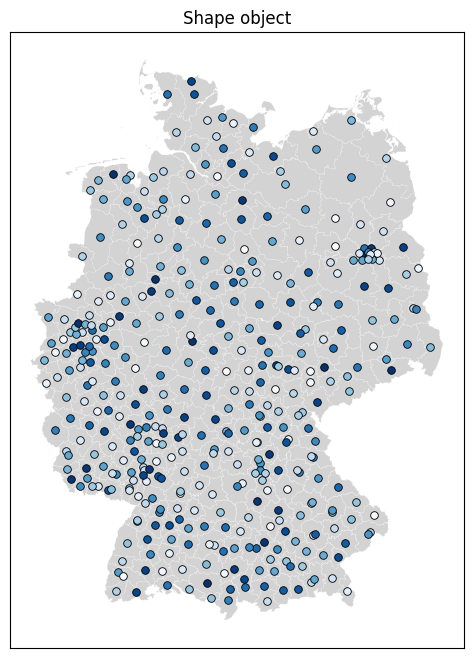

In [8]:
epidata_nuts3 = EpiDataLoader('norovirus', data_env, nuts_level='nuts3', min_date='2006-05-15',max_date='2020-06-01', include_population=True)
graphconstruction_nuts3 = GraphConstructor(graph_dir = 'data/graphs', 
                                     epidata   = epidata_nuts3,
                                     id_col    = 'node')
graphconstruction_nuts3.preview_shape_object()

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


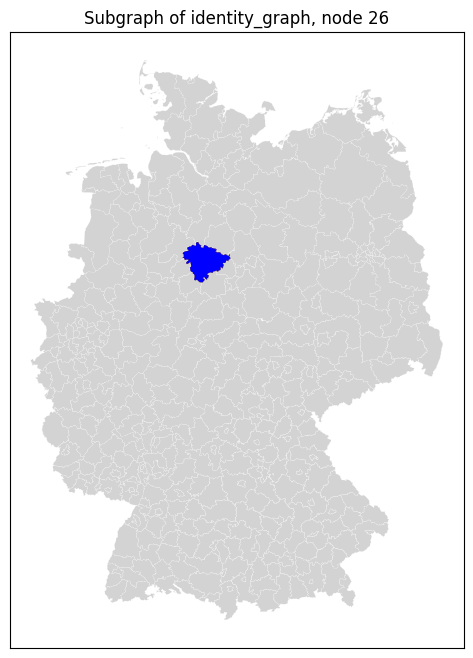

In [10]:
graphconstruction.preview_graph(graphname='identity_graph', node_idx = 26)

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


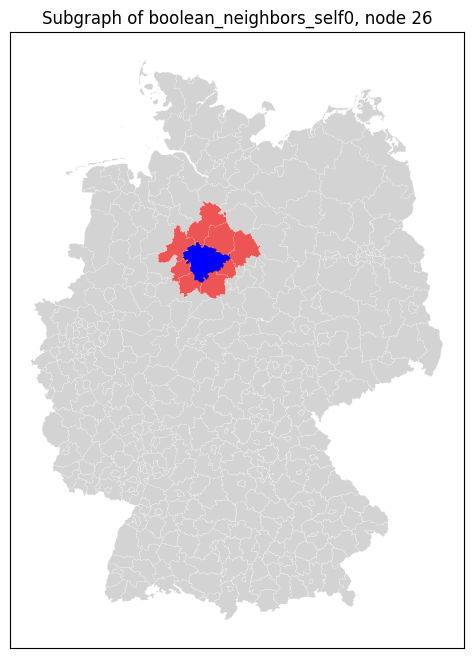

In [7]:
graphconstruction.preview_graph(graphname='boolean_neighbors_self0', node_idx = 26)

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


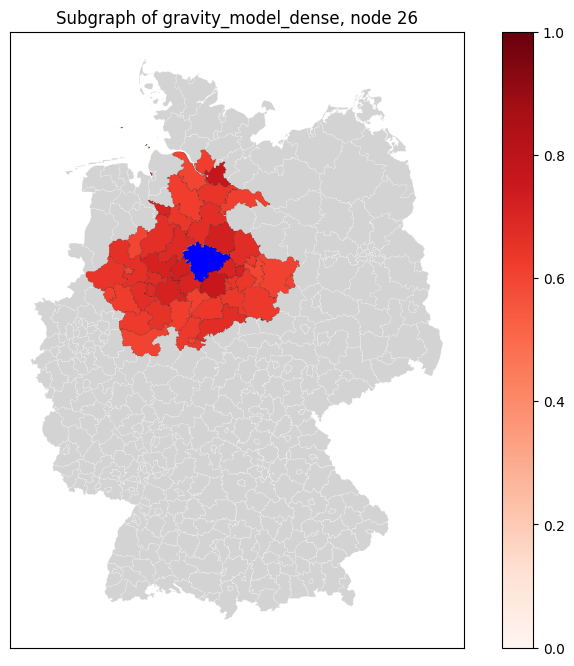

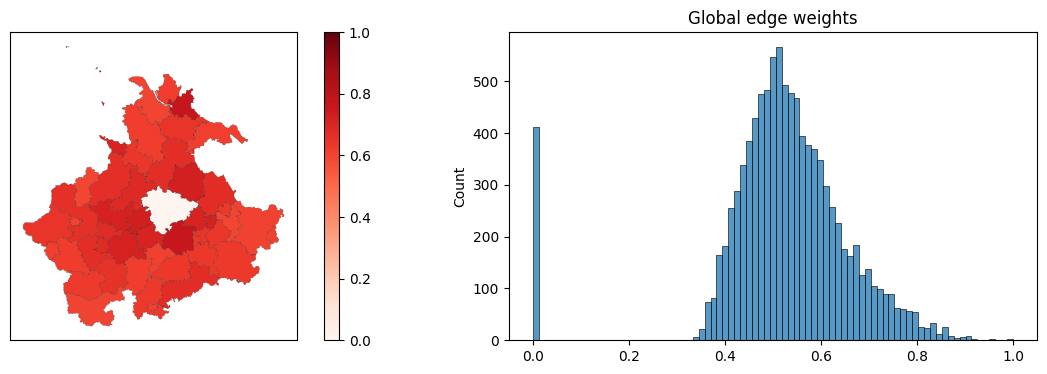

In [8]:
graphconstruction.preview_graph(graphname='gravity_model_dense', node_idx = 26)

/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


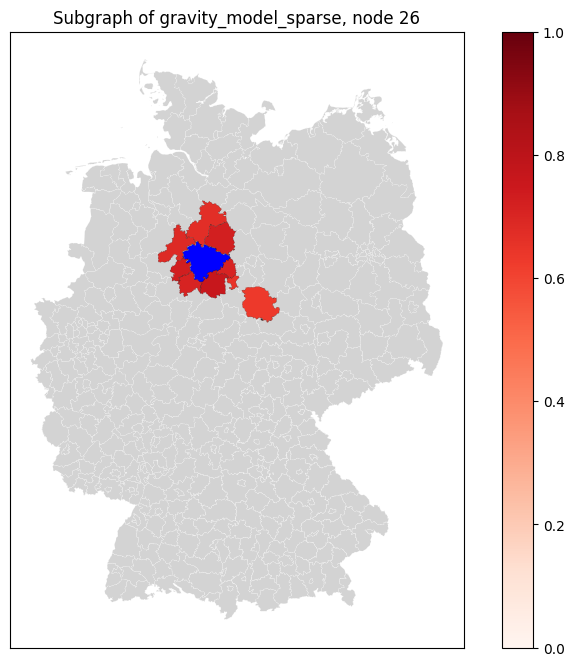

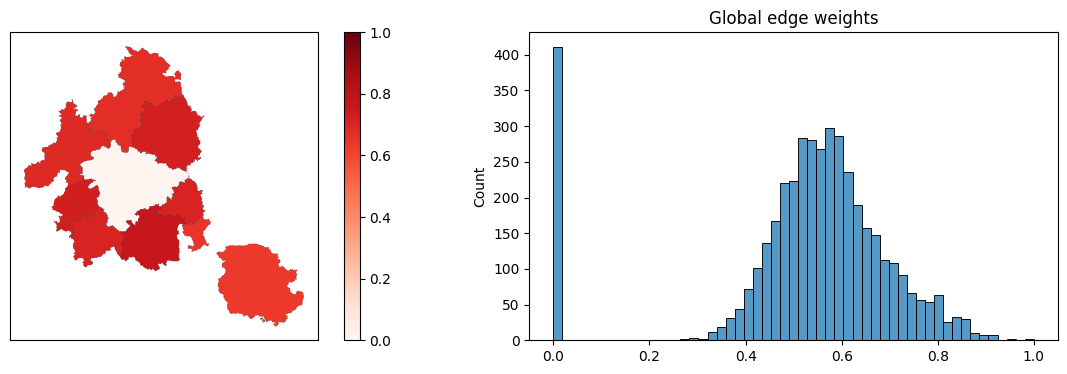

In [9]:
graphconstruction.preview_graph(graphname='gravity_model_sparse', node_idx = 26)